In [3]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

 - 

## variable discriptions
| 欄位 | 描述|
|---|---|
| NAICS | 這些資料為描述美國經濟狀況的統計數據。NAICS 產業分類中的前兩位數用來表示所屬的經濟部門。表 2 彙整了各 2 位數產業部門及其對應的產業說明。|
| franchisecode：| 00000or000010代表沒有frabchise(沒有加盟的意思) |
|newexist: |1=existing business, 2=new business|
|noemp:|number of business employees
|term:|loan term in month
|approvalfy:|fiscal year ofcommitment(SBA 在哪一個「會計年度」核准這筆貸款)
|DateSBAcommitmentissued:|「SBA（美國小企業署）核准／發出貸款承諾的日期」
|UrbanRural:|1=Urban,2=rural,0=undefined
|RevLineCr Revolving line of credit:|Y=Yes,N=No (貸款種類是不是一筆循環貸款)
|lodoc:|y=yes,n=no是不是低文件貸款方案
|ChgOffDate | The date when aloan is declared to be in default
|DisbursementDate | Disbursement date (撥款日期)
|DisbursementGross| Currency Amount disbursed (實際撥款金額)
|BalanceGross Currency | Gross amount outstanding(尚未償還的總貸款金額)
|MIS_Status: | Loan status charged off = CHGOFF,Paid in full =PIF(charged off =呆帳,paid in full=已償還) |
|ChgOffPrinGr |  Charged-offamount👉 實際發生違約後，被銀行認列為損失的金額 |
|grappv | Gross amount of loan approved by bank 銀行核准的貸款總金額（原始貸款額）|
|sba_appv  |SBA’s guaranteed amount of approved loan SBA 對這筆貸款「提供擔保」的金額|

In [ ]:
import pandas as pd
df = pd.read_csv("data/SBAnational.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/SBAnational.csv'

In [4]:
#資料前處理
#把$字號拿掉轉成數值型欄位
cn = ['SBA_Appv','GrAppv','ChgOffPrinGr','BalanceGross','DisbursementGross']

for c in cn:
    df[c] = df[c].astype(str).str.replace(r'[$, ]', '', regex=True)
    df[c] = pd.to_numeric(df[c], errors='coerce')
#缺失值處理
#把想了解的y欄位有缺失值的資料刪掉
df = df.dropna(subset=['MIS_Status'])
#把ChgOffDate欄位刪掉，因為缺失值達82%
df = df.drop(columns=['ChgOffDate'])

In [5]:
#把沒用的欄位刪掉
delete = ['LoanNr_ChkDgt','Name','City','Zip','Bank','ChgOffPrinGr'] #把chgoffpringr刪掉，因為它是chgoffprin的衍生欄位，會造成資料洩漏
df = df.drop(columns=delete)

In [6]:
#缺失值處理
#State以n取代缺失值
df['State'] = df['State'].fillna('n')   

In [7]:
#刪除NewExist缺失的資料
df = df.dropna(subset=['NewExist'])

In [8]:
#把RevLine 和LowDoc的缺失值以nan取代
df['RevLineCr'] = df['RevLineCr'].fillna('nan')
df['LowDoc'] = df['LowDoc'].fillna('nan')

In [9]:
#處理日期
# 轉成 Pandas 時間格式後，計算距離某個基準點的天數，刪掉原本的日期
df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'])
df['Days_Since_Appv'] = (df['ApprovalDate'] - df['ApprovalDate'].min()).dt.days
df = df.drop(columns=['ApprovalDate'])

#處理日期
# 轉成 Pandas 時間格式後，計算距離某個基準點的天數，刪掉原本的日期
df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'])
df['Days_Since_Disb'] = (df['DisbursementDate'] - df['DisbursementDate'].min()).dt.days
df = df.drop(columns=['DisbursementDate'])

C:\Users\a0928\AppData\Local\Temp\ipykernel_18460\4014428504.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'])
C:\Users\a0928\AppData\Local\Temp\ipykernel_18460\4014428504.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'])


In [10]:
#把Days_Since_Disb欄位的缺失值以中位數取代
df['Days_Since_Disb'] = df['Days_Since_Disb'].fillna(df['Days_Since_Disb'].median())

 - 開始文字轉數字

In [11]:
#將franchisecode欄位的00000or00001標為0其餘為1
df['FranchiseCode_Binary'] = df['FranchiseCode'].apply(lambda x: 0 if x in [0, 1] else 1)
df = df.drop(columns=['FranchiseCode'])

In [ ]:
# import missingno as msno
# import matplotlib.pyplot as plt

# # 挑選你想檢查的兩個欄位（bank,bankstate）
# cols = ['BankState']
# msno.heatmap(df[cols])
# plt.show()
# #發現重合程度超高，於是想建立子資料及觀察更多欄位
# # 抓出 Bank 欄位缺失的所有資料

# # 看看這個子資料集的大小
# print(f"缺失資料筆數: {df_missing.shape[0]}")


In [53]:
#df_specific_missing = df[(df['Bank'] == 'Missing_Data') & (df['BankState'] == 'MD')].copy()

# 查看結果
#print(f"符合條件的筆數: {df_specific_missing.shape[0]}")
#print(df_specific_missing.head())

#查看資料發現MISSING的借貸資料(GrAppv)都偏低，相較於整體資料的偏態跟紐曲都較小，代表他們的借貸行為較為穩定，違約率也較低

#原始資料做特徵工程建立一個欄位，告訴AI這些資料的人比較乖
#df['Is_Missing_Group'] = (df['Bank'] == 'Missing_Data').astype(int)

符合條件的筆數: 1506
             City State    Zip          Bank BankState   NAICS ApprovalDate  \
407    MOUNTVILLE    PA  17554  Missing_Data        MD       0    27-Jun-80   
680     CLEVELAND    OH  44114  Missing_Data        MD       0     8-Jul-80   
16108      DALLAS    TX  75220  Missing_Data        MD  235420    10-Apr-97   
18188   GALESBURG    KS  66740  Missing_Data        MD       0    15-Dec-80   
27779    LONGVIEW    TX  75606  Missing_Data        MD       0     7-Apr-81   

      ApprovalFY  Term  NoEmp  ...  RevLineCr  LowDoc  DisbursementDate  \
407         1980   120     57  ...          N       N         25-Jul-80   
680         1980   120     18  ...          N       N         21-Aug-80   
16108       1997    84     10  ...          N       Y         31-May-97   
18188       1981   120      8  ...          N       N         15-Dec-81   
27779       1981   126      1  ...          N       N         22-Apr-81   

       DisbursementGross  BalanceGross MIS_Status ChgOffPrin

In [12]:
#處理NAICS的資料，依據他的前兩個數字做分類
df['NAICS_Section'] = df['NAICS'].astype(str).str[:2]

# 處理無效的 NAICS (例如原始資料可能是 0，轉字串後變 '0')
# 建議將其標記為 'Unknown' 或一個特定的類別
df['NAICS_Section'] = df['NAICS_Section'].replace(['0', '00', 'na', 'n'], 'Unknown')

In [13]:
#刪除NAICS欄位
df = df.drop(columns=['NAICS'])

In [14]:
#切X Y
X = df.drop(columns=['MIS_Status'])
y = df['MIS_Status']

In [ ]:
#切訓練 測試
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"訓練集大小: {X_train.shape[0]}，測試集大小: {X_test.shape[0]}")

訓練集大小: 717626，測試集大小: 179407


In [16]:
import category_encoders as ce

# 1. 初始化 Target Encoder，指定你要轉換的兩個欄位
# cols 參數傳入一個列表，包含 'State' 和 'BankState'
target_enc = ce.TargetEncoder(cols=['State', 'BankState','NAICS_Section','ApprovalFY'])

# 2. 擬合 (Fit)：讓編碼器從訓練集中學習這兩個欄位與違約 (y_train) 的關係
# 它會分別為 State 和 BankState 建立兩張「違約率對照表」
target_enc.fit(X_train, y_train)

# 3. 轉換 (Transform)：將對照表的數值填入訓練集與測試集
# 這裡就是你說的「對應」：測試集的州名會對應到訓練集算出的違約率
X_train = target_enc.transform(X_train)
X_test = target_enc.transform(X_test)

In [17]:
#覺得借貸金額極端值太嚴重，最大值和最小值超過2個數量級，可能需要先做標準化或取對數等行為以幫助接下來機器學習
colstolog = ['BalanceGross','SBA_Appv','GrAppv','DisbursementGross']

#對這些欄位取對數
X_train[colstolog] = X_train[colstolog].apply(np.log1p)
X_test[colstolog] = X_test[colstolog].apply(np.log1p)
print(X_train.head())

           State  BankState  ApprovalFY  Term  NoEmp  NewExist  CreateJob  \
686529  0.815217   0.779194    0.814185   120      6       1.0          0   
614930  0.801432   0.910126    0.977425   180      6       1.0          0   
108554  0.793787   0.822769    0.918593   300      9       1.0          0   
722523  0.887464   0.917235    0.977022   180      1       1.0          0   
662182  0.870689   0.795670    0.854465    84      6       1.0          0   

        RetainedJob  UrbanRural RevLineCr LowDoc  DisbursementGross  \
686529            0           1         N      N          11.695255   
614930            0           0         N      N          13.304687   
108554            0           0         0      N          12.586223   
722523            0           0         N      Y          11.264477   
662182            6           1         Y      N          11.315949   

        BalanceGross     GrAppv   SBA_Appv  Days_Since_Appv  Days_Since_Disb  \
686529           0.0  11.69525

In [ ]:
#發現newexist為0的資料其超過90%為循環貸款，跟普遍的不同 考慮做研究
#g = df[df['NewExist']==0]

bank 缺1500
bankstate 缺1600 上面兩種有關係

chgoffdate缺失值達82%--刪掉
mis_state的缺失值資料直接刪除

NewExist資料應該只有種類1,2但還有0、空值，把後面兩種刪掉
revlinecr遺漏4500
lowdoc遺漏2500
disbursementdate缺2300考慮刪除

In [18]:
#資料前處理-one-hot encoding
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False,drop='first') # drop='first' 可以避免虛擬變數陷阱
encoded_data = enc.fit_transform(X_train[['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']])

encoded_df = pd.DataFrame(
    encoded_data, 
    columns=enc.get_feature_names_out(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']),
    index=X_train.index # 關鍵：確保索引一致，合併才不會錯位
)

# --- 新增：合併回原始 DataFrame 並移除舊欄位 ---
# 這樣你的 df_final 就會包含「對數轉換後的金額」+「One-Hot 欄位」
X_train_final = pd.concat([X_train.drop(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc'], axis=1), encoded_df], axis=1)

print(X_train_final.head())



           State  BankState  ApprovalFY  Term  NoEmp  CreateJob  RetainedJob  \
686529  0.815217   0.779194    0.814185   120      6          0            0   
614930  0.801432   0.910126    0.977425   180      6          0            0   
108554  0.793787   0.822769    0.918593   300      9          0            0   
722523  0.887464   0.917235    0.977022   180      1          0            0   
662182  0.870689   0.795670    0.854465    84      6          0            6   

        DisbursementGross  BalanceGross     GrAppv  ...  RevLineCr_nan  \
686529          11.695255           0.0  11.695255  ...            0.0   
614930          13.304687           0.0  13.304687  ...            0.0   
108554          12.586223           0.0  12.586223  ...            0.0   
722523          11.264477           0.0  11.264477  ...            0.0   
662182          11.315949           0.0  10.596660  ...            0.0   

        FranchiseCode_Binary_1  LowDoc_1  LowDoc_A  LowDoc_C  LowDoc_N  \


In [19]:
#X_test也做一樣的處理
encoded_data_test = enc.transform(X_test[['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']])
encoded_df_test = pd.DataFrame(
    encoded_data_test,
    columns=enc.get_feature_names_out(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']),
    index=X_test.index
)
X_test_final = pd.concat([X_test.drop(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc'], axis=1), encoded_df_test], axis=1)
print(X_test_final.head())

           State  BankState  ApprovalFY  Term  NoEmp  CreateJob  RetainedJob  \
197459  0.725856   0.841928    0.650591   240      4          2            0   
225014  0.821782   0.936329    0.571424   300     20          0           20   
281775  0.809674   0.858497    0.564031   240     26         12           14   
707918  0.725856   0.706531    0.822480    25      4          1            4   
314219  0.836627   0.778500    0.588259     4      1          0            1   

        DisbursementGross  BalanceGross     GrAppv  ...  RevLineCr_nan  \
197459          12.818555           0.0  12.818555  ...            0.0   
225014          13.552848           0.0  13.552848  ...            0.0   
281775          12.138869           0.0  12.138869  ...            0.0   
707918          10.596660           0.0   9.903538  ...            0.0   
314219          12.450982           0.0  12.450982  ...            0.0   

        FranchiseCode_Binary_1  LowDoc_1  LowDoc_A  LowDoc_C  LowDoc_N  \


d:\桌面\python數據分析實習\重新做一個作品\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [20]:
y_train = y_train.apply(lambda x: 1 if x == 'CHGOFF' else 0)
y_test = y_test.apply(lambda x: 1 if x == 'CHGOFF' else 0)

In [21]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# #選擇要標準化的欄位
# num_cols = ['State','BankState','ApprovalFY','Term','NoEmp','CreateJob','RetainedJob','DisbursementGross','BalanceGross','GrAppv', 'SBA_Appv','Days_Since_Appv'
#             ,'Days_Since_Disb','NAICS_Section' ]

In [48]:
#改成動態抓取數值型欄位，這樣以後如果有新增數值型欄位就不會忘記標準化了
num_cols = X_train_final.select_dtypes(include="number").columns.tolist()

In [49]:
# 1. 初始化標準化器
scaler = StandardScaler()

# 2. 建立副本，避免改動到原始切分好的資料
X_train_scaled = X_train_final.copy()
X_test_scaled = X_test_final.copy()

# 3. 關鍵步驟：只對「訓練集」進行 Fit（學習平均值與標準差）
# 然後同時對「訓練集」與「測試集」進行 Transform
X_train_scaled[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_final[num_cols])

# 檢查結果：平均值應接近 0，標準差應接近 1
print("訓練集平均值:\n", X_train_scaled[num_cols].mean().round(2))
print("訓練集標準差:\n", X_train_scaled[num_cols].std().round(2))

訓練集平均值:
 State                     0.0
BankState                 0.0
ApprovalFY                0.0
Term                      0.0
NoEmp                    -0.0
CreateJob                 0.0
RetainedJob              -0.0
DisbursementGross        -0.0
BalanceGross              0.0
GrAppv                    0.0
SBA_Appv                  0.0
Days_Since_Appv           0.0
Days_Since_Disb          -0.0
NAICS_Section             0.0
NewExist_1.0              0.0
NewExist_2.0             -0.0
UrbanRural_1             -0.0
UrbanRural_2              0.0
RevLineCr_.               0.0
RevLineCr_0               0.0
RevLineCr_1               0.0
RevLineCr_2               0.0
RevLineCr_3               0.0
RevLineCr_4               0.0
RevLineCr_5               0.0
RevLineCr_7               0.0
RevLineCr_A               0.0
RevLineCr_C               0.0
RevLineCr_N              -0.0
RevLineCr_Q               0.0
RevLineCr_R               0.0
RevLineCr_T              -0.0
RevLineCr_Y               0.0
R

In [24]:
from sklearn.linear_model import ElasticNetCV

In [50]:
en_cv = ElasticNetCV(
    l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
    cv=5, 
    random_state=42, 
    max_iter=5000  # 增加迭代次數確保收斂
)

In [51]:
en_cv.fit(X_train_scaled, y_train)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.5, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [52]:
# 1. 找出係數不為 0 的特徵名稱
selected_features = X_train_scaled.columns[en_cv.coef_ != 0].tolist()

print(f"原始特徵數量: {X_train_scaled.shape[1]}")
print(f"篩選後特徵數量: {len(selected_features)}")
print("被選中的特徵:", selected_features)

# 2. 重新定義訓練集與測試集，只保留這些精華特徵
X_train_reduced = X_train_scaled[selected_features]
X_test_reduced = X_test_scaled[selected_features]

原始特徵數量: 44
篩選後特徵數量: 37
被選中的特徵: ['State', 'BankState', 'ApprovalFY', 'Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross', 'BalanceGross', 'GrAppv', 'SBA_Appv', 'Days_Since_Appv', 'Days_Since_Disb', 'NAICS_Section', 'NewExist_1.0', 'UrbanRural_1', 'UrbanRural_2', 'RevLineCr_.', 'RevLineCr_2', 'RevLineCr_3', 'RevLineCr_5', 'RevLineCr_7', 'RevLineCr_C', 'RevLineCr_N', 'RevLineCr_R', 'RevLineCr_T', 'RevLineCr_Y', 'RevLineCr_`', 'RevLineCr_nan', 'FranchiseCode_Binary_1', 'LowDoc_1', 'LowDoc_A', 'LowDoc_C', 'LowDoc_N', 'LowDoc_S', 'LowDoc_Y', 'LowDoc_nan']


 - 開套模型咯

In [53]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

In [54]:
## 方案 A：使用 Random Forest訓練
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_reduced, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
#套入模型
y_pred = rf_model.predict(X_test_reduced)
y_test_proba = rf_model.predict_proba(X_test_reduced)[:, 1]

In [ ]:
#  ## 方案 B：使用 XGBoost 訓練
# xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
# xgb_model.fit(X_train_reduced, y_train) 

d:\桌面\python數據分析實習\重新做一個作品\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:37:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

 - 可加上grid research找到最好的模型

In [ ]:
# #訓練套入模型
# y_train_pred= xgb_model.predict(X_train_reduced)
# y_train_proba = xgb_model.predict_proba(X_train_reduced)[:, 1]

In [ ]:
# #測試套入模型
# y_test_pred = xgb_model.predict(X_test_reduced)
# y_test_proba = xgb_model.predict_proba(X_test_reduced)[:, 1]

In [108]:
# 方案 B：使用 gridsearch (如果資料很大，通常比 RF 更準)
#1. 初始化模型，先用預設參數訓練看看表現
#xgb_model = XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', random_state=42)


# 2. 設定想要測試的參數網格 (Grid)
# 建議針對關鍵參數進行測試，避免跑太久
#param_grid = {
#    'n_estimators': [100, 200],           # 樹的棵數
#    'max_depth': [3, 6, 9],               # 樹的深度 (3-10 是常見區間)
#    'learning_rate': [0.01, 0.1, 0.2],    # 學習率 (步長)
#    'subsample': [0.8, 1.0]               # 每次訓練取用的資料比例
#}

# 3. 初始化 GridSearchCV
# cv=3 代表做三折交叉驗證；n_jobs=-1 代表使用電腦所有核心加速跑
#grid_xgb = GridSearchCV(
#    estimator=xgb_model,
#    param_grid=param_grid,
#    cv=3, 
#    scoring='f1',       # 因為是分類問題，用 F1 或 ROC-AUC 比較專業
#    n_jobs=-1,
#    verbose=2           # 讓你看到跑的進度
#)

#4
#grid_xgb.fit(X_train_reduced, y_train)

# 5. 輸出結果
#print(f"最佳參數組合: {grid_xgb.best_params_}")
#print(f"最佳 F1 分數: {grid_xgb.best_score_:.4f}")  
# 6. 取得最強模型來做最後的預測
#final_xgb = grid_xgb.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits


KeyboardInterrupt: 

In [56]:
#結果分析(一)查看分類報告
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97    147940
           1       0.90      0.78      0.83     31467

    accuracy                           0.94    179407
   macro avg       0.92      0.88      0.90    179407
weighted avg       0.94      0.94      0.94    179407



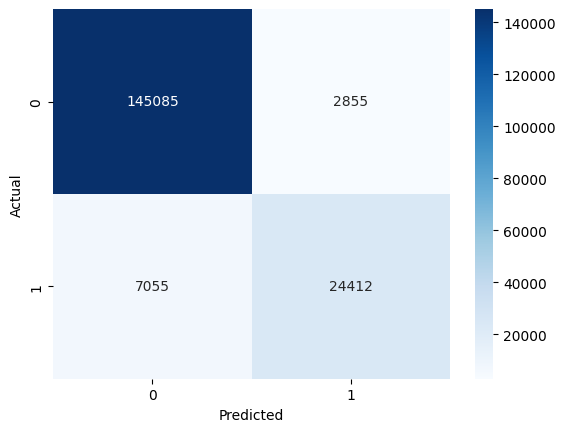

In [57]:
#結果分析(二)混淆矩陣
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [58]:
#結果分析(三)查看AUC分數
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_test_proba) # 記得用機率值而不是 0/1 類別
print(f"AUC Score: {auc}")

AUC Score: 0.9695629005477837


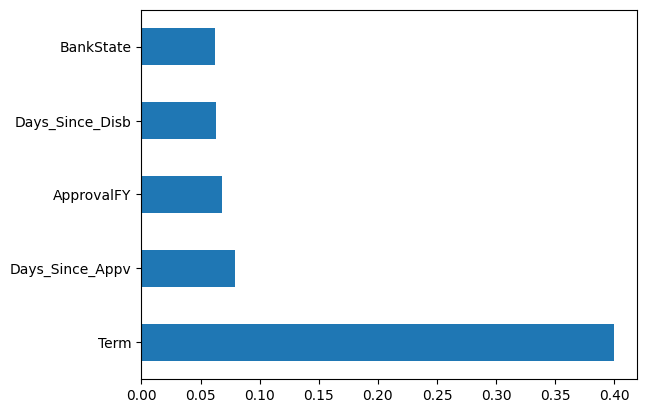

In [59]:
import matplotlib.pyplot as plt
feat_importances = pd.Series(rf_model.feature_importances_, index=X_test_reduced.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.show()

In [ ]:
# #儲存完成的模型
# # 假設你的模型變數名稱是 final_xgb_model
# xgb_model.save_model("model/sba_xgboost_model.json")

# print("XGBoost 模型已成功儲存為 JSON 格式！")

XGBoost 模型已成功儲存為 JSON 格式！


 - 準備 power bi 資料的程式碼

In [141]:
power_bi_df = X_test_reduced.copy()

# 1. 補回原始金額 (從原始 df 找回，不要用對數後的)
power_bi_df['Original_Amount'] = df.loc[X_test_reduced.index, 'GrAppv']

# 2. 加入預測結果
power_bi_df['Default_Probability'] = y_test_proba 
power_bi_df['Actual_Status'] = y_test

# 3. 匯出
power_bi_df.to_csv("reports/power_bi_data.csv", index=False)